In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, f1_score
)

%matplotlib inline

In [2]:
train = pd.read_csv('../data/processed/training_xgb_rf.csv')
test  = pd.read_csv('../data/processed/test_xgb_rf.csv')

X_train = train.drop(columns=['label'])
y_train = train['label']
X_test  = test.drop(columns=['label'])
y_test  = test['label']

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Class balance (train) — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}')

Train: (107740, 58), Test: (55945, 58)
Class balance (train) — 0: 51890, 1: 55850


In [3]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

base_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

## Hyperparameter Tuning

In [4]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 4, 6, 8, 10],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.7, 0.8, 1.0],
    'min_child_weight':  [1, 3, 5, 7],
    'gamma':             [0, 0.1, 0.3, 0.5],
}

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print(f'Best ROC-AUC (CV): {search.best_score_:.4f}')
print(f'Best params:       {search.best_params_}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best ROC-AUC (CV): 0.9636
Best params:       {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.7}


In [5]:
model = search.best_estimator_

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-logloss:0.64757
[50]	validation_0-logloss:0.36449
[99]	validation_0-logloss:0.32385


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Base Evaluation, threshold = 0.5

In [6]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

              precision    recall  f1-score   support

      Normal       0.98      0.70      0.82     34206
      Attack       0.68      0.98      0.80     21739

    accuracy                           0.81     55945
   macro avg       0.83      0.84      0.81     55945
weighted avg       0.86      0.81      0.81     55945

ROC-AUC: 0.9641


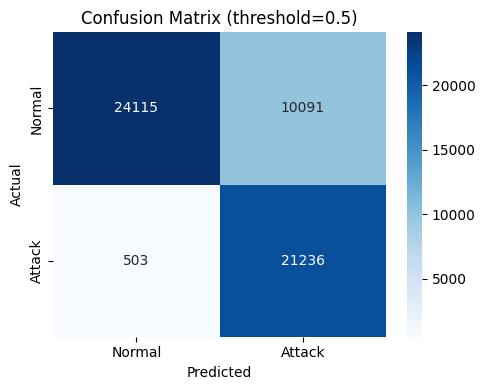

In [7]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title('Confusion Matrix (threshold=0.5)')
plt.tight_layout()
plt.show()

## Threshold Tuning

In cybersecurity, false negatives (missed attacks) are more costly than false positives.
We find the threshold that maximises F1, then also examine the recall-precision tradeoff.

Optimal threshold (max F1):     0.70  — F1: 0.8624, Recall: 0.8906
Optimal threshold (max Recall): 0.01  — F1: 0.7163, Recall: 1.0000
Default threshold (0.5):               — F1: 0.8004, Recall: 0.9769


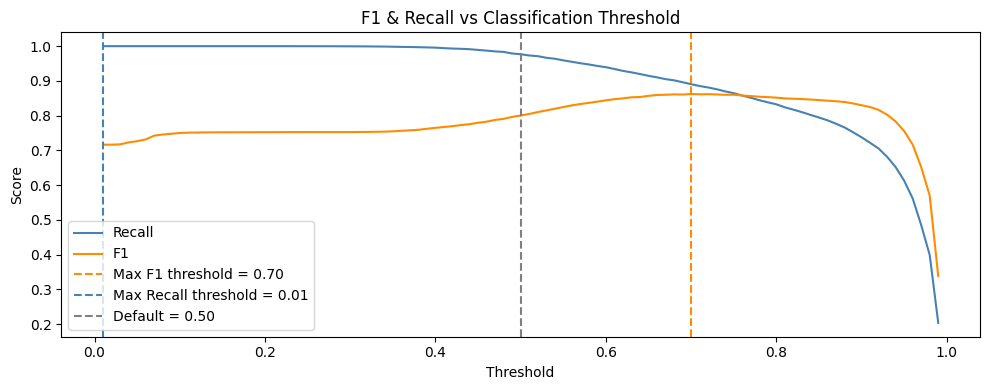

In [8]:
from sklearn.metrics import recall_score

thresholds    = np.arange(0.01, 1.0, 0.01)
f1_scores     = [f1_score(y_test,    (y_prob >= t).astype(int)) for t in thresholds]
recall_scores = [recall_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]

best_f1_threshold     = thresholds[np.argmax(f1_scores)]
best_recall_threshold = thresholds[np.argmax(recall_scores)]

print(f'Optimal threshold (max F1):     {best_f1_threshold:.2f}  — F1: {max(f1_scores):.4f}, Recall: {recall_scores[np.argmax(f1_scores)]:.4f}')
print(f'Optimal threshold (max Recall): {best_recall_threshold:.2f}  — F1: {f1_scores[np.argmax(recall_scores)]:.4f}, Recall: {max(recall_scores):.4f}')
print(f'Default threshold (0.5):               — F1: {f1_scores[49]:.4f}, Recall: {recall_scores[49]:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, recall_scores, color='steelblue', label='Recall')
ax.plot(thresholds, f1_scores, color='darkorange', label='F1')
ax.axvline(best_f1_threshold,     color='darkorange', linestyle='--', label=f'Max F1 threshold = {best_f1_threshold:.2f}')
ax.axvline(best_recall_threshold, color='steelblue',  linestyle='--', label=f'Max Recall threshold = {best_recall_threshold:.2f}')
ax.axvline(0.5, color='gray', linestyle='--', label='Default = 0.50')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('F1 & Recall vs Classification Threshold')
ax.legend()
plt.tight_layout()
plt.show()

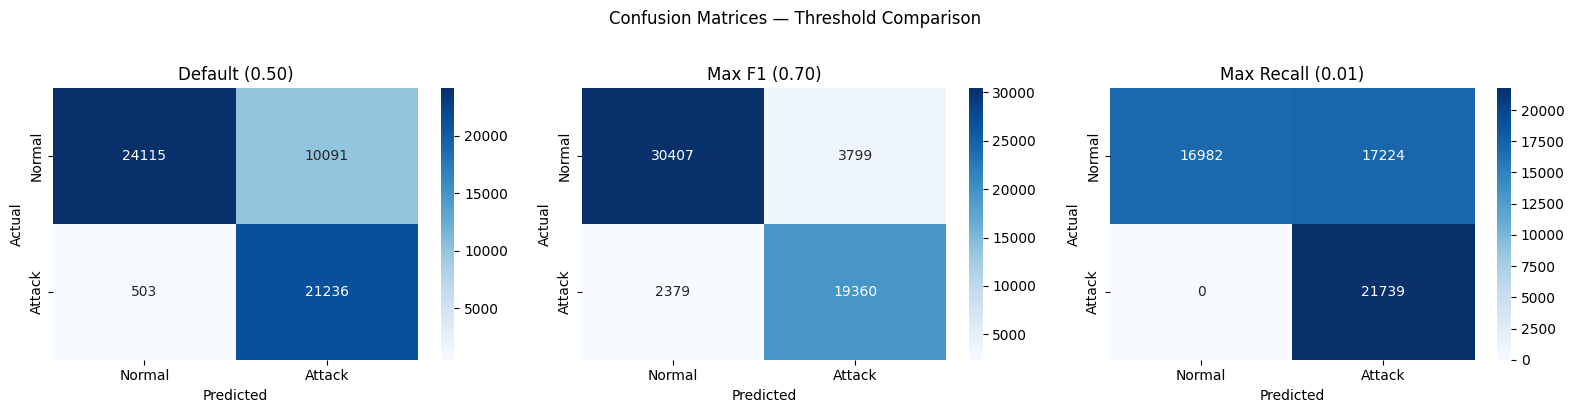


Chosen threshold: 0.70 (max F1)
              precision    recall  f1-score   support

      Normal       0.93      0.89      0.91     34206
      Attack       0.84      0.89      0.86     21739

    accuracy                           0.89     55945
   macro avg       0.88      0.89      0.89     55945
weighted avg       0.89      0.89      0.89     55945



In [9]:
optimal_threshold = best_f1_threshold

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (t, title) in zip(axes, [
    (0.5,                  'Default (0.50)'),
    (best_f1_threshold,    f'Max F1 ({best_f1_threshold:.2f})'),
    (best_recall_threshold, f'Max Recall ({best_recall_threshold:.2f})'),
]):
    preds = (y_prob >= t).astype(int)
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.set_title(title)
plt.suptitle('Confusion Matrices — Threshold Comparison', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nChosen threshold: {optimal_threshold:.2f} (max F1)')
print(classification_report(y_test, (y_prob >= optimal_threshold).astype(int), target_names=['Normal', 'Attack']))

In [11]:
optimal_threshold = best_f1_threshold
y_pred_tuned = (y_prob >= optimal_threshold).astype(int)

## Per-Attack-Category Breakdown

Join predictions against the raw test data to evaluate performance per attack type.

In [12]:
raw_test = pd.read_csv('../data/raw/UNSW_NB15_testing-set.csv')

raw_test = raw_test.drop_duplicates(subset=[c for c in raw_test.columns if c != 'id']).reset_index(drop=True)

results = raw_test[['attack_cat']].copy()
results['y_true']       = y_test.values
results['y_pred']       = y_pred_tuned
results['y_prob']       = y_prob

results.head()

,attack_cat,y_true,y_pred,y_prob
0,Normal,0,1,0.855952
1,Normal,0,1,0.824892
2,Normal,0,1,0.734551
3,Normal,0,1,0.734551
4,Normal,0,1,0.719810


In [13]:
def attack_metrics(group):
    tp = ((group['y_true'] == 1) & (group['y_pred'] == 1)).sum()
    fn = ((group['y_true'] == 1) & (group['y_pred'] == 0)).sum()
    fp = ((group['y_true'] == 0) & (group['y_pred'] == 1)).sum()
    tn = ((group['y_true'] == 0) & (group['y_pred'] == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return pd.Series({'count': len(group), 'precision': round(precision, 4),
                      'recall': round(recall, 4), 'f1': round(f1, 4)})

breakdown = results.groupby('attack_cat').apply(attack_metrics).sort_values('recall')
print(breakdown.to_string())

                  count  precision  recall      f1
attack_cat                                        
Normal          34206.0        0.0  0.0000  0.0000
Fuzzers          4838.0        1.0  0.5701  0.7262
Analysis          446.0        1.0  0.8901  0.9419
Shellcode         378.0        1.0  0.9683  0.9839
Exploits         7609.0        1.0  0.9786  0.9892
DoS              1718.0        1.0  0.9796  0.9897
Backdoor          346.0        1.0  0.9884  0.9942
Reconnaissance   2703.0        1.0  0.9911  0.9955
Generic          3657.0        1.0  0.9967  0.9984
Worms              44.0        1.0  1.0000  1.0000


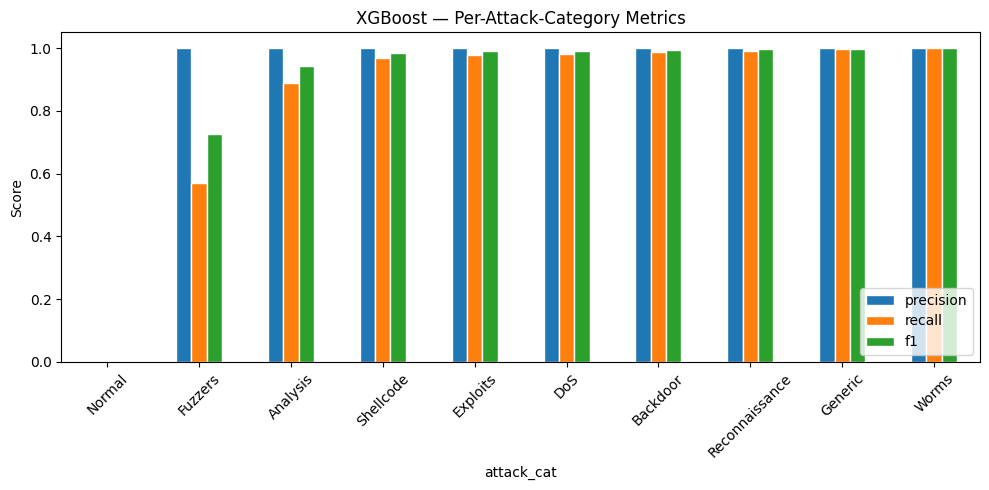

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
breakdown[['precision', 'recall', 'f1']].plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('XGBoost — Per-Attack-Category Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Feature Importance

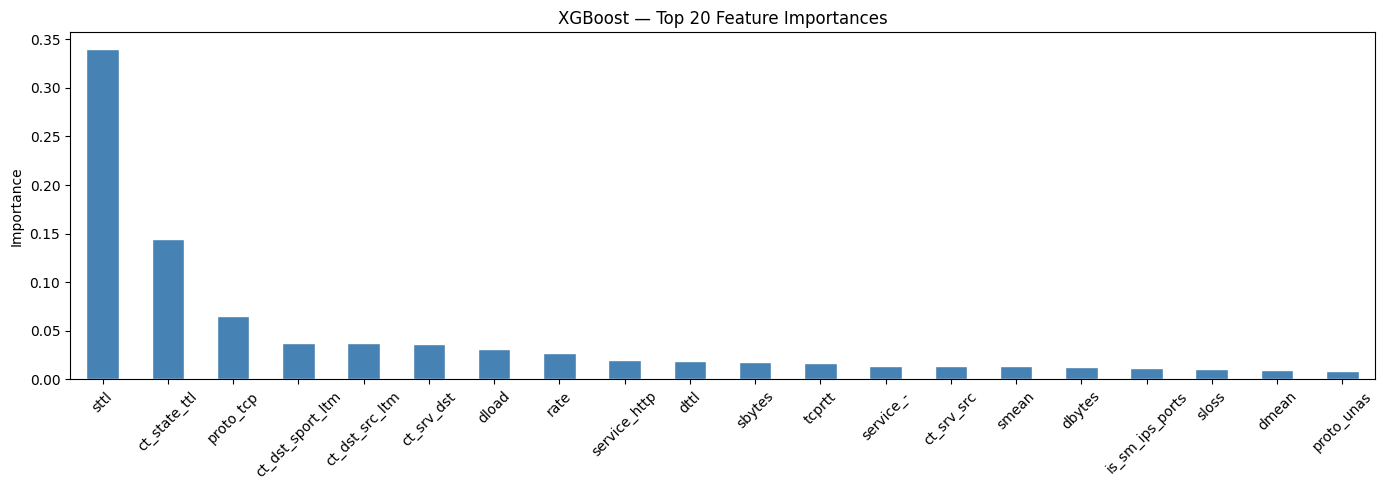

In [15]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
importances.head(20).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('XGBoost — Top 20 Feature Importances')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()